<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/DSP_1_PRATICA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prática 3 Exercício 1

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_957/2591885157.py:27: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Parte Real ($\sigma$)')
/tmp/ipykernel_957/2591885157.py:28: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Parte Imaginária ($j\omega$)')


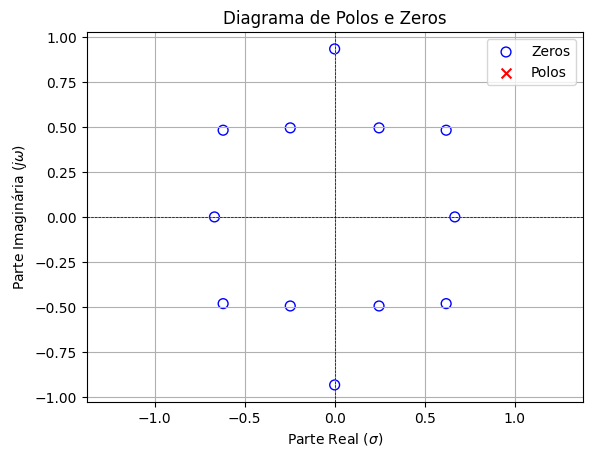

In [18]:
import numpy as np
import matplotlib.pyplot as plot
from scipy import signal

num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
den = [1]

w = np.logspace (-1, 10, 200)

w_out, H = signal.freqresp((num, den), w)

magnitude = np.abs(H)
fase = np.angle(H, deg = True)

#ZEROS E POLOS
zeros, polos, k = signal.tf2zpk(num, den)

fig, ax = plt.subplots()

ax.scatter (np.real(zeros), np.imag(zeros), s = 50, marker = 'o', facecolors = 'none', edgecolors = 'b', label = 'Zeros')
ax.scatter (np.real(polos), np.imag(polos), s = 50, marker = 'x', color = 'r', label = 'Polos')

ax.axhline (y = 0, color = 'k', linestyle = '--', linewidth = 0.5)
ax.axvline (x = 0, color = 'k', linestyle = '--', linewidth = 0.5)

ax.set_title('Diagrama de Polos e Zeros')
ax.set_xlabel('Parte Real ($\sigma$)')
ax.set_ylabel('Parte Imaginária ($j\omega$)')
ax.grid(True)
ax.legend()
ax.axis('equal')

plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_957/1348085257.py:33: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')


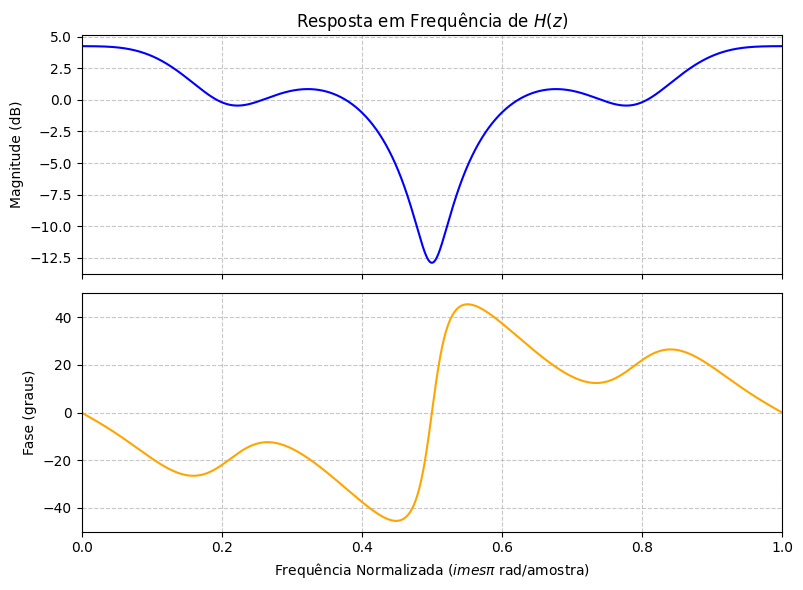

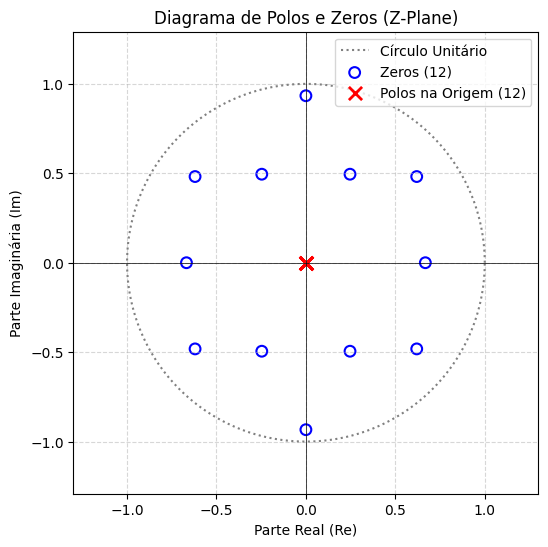

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes originais do numerador de z^12 até z^0
num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]

# Denominador correspondente a z^12 (1 seguido de 12 zeros)
den = [1] + [0] * 12

# Resposta em frequencia
# Calcula a resposta em frequência (w em rad/amostra, H é complexo)
# worN=8000 define a resolução do gráfico (8000 pontos)
w, H = signal.freqz(num, den, worN=8000)

# Extrai Magnitude (em decibéis) e Fase (em graus)
magnitude_db = 20 * np.log10(np.abs(H))
fase_graus = np.degrees(np.unwrap(np.angle(H)))

# --- Plotando os Gráficos ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 1. Gráfico de Magnitude
ax1.plot(w / np.pi, magnitude_db, color='blue', linewidth=1.5)
ax1.set_title('Resposta em Frequência de $H(z)$')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfico de Fase
ax2.plot(w / np.pi, fase_graus, color='orange', linewidth=1.5)
ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')
ax2.set_ylabel('Fase (graus)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajusta o eixo X para ir de 0 a 1 (0 a pi rad)
ax2.set_xlim([0, 1])

plt.tight_layout()

#CALCULOS DE POLOS DE ZEROS

# Calcula analiticamente todos os zeros e polos exatos
zeros, polos, k = signal.tf2zpk(num, den)

# Cria a figura
fig, ax = plt.subplots(figsize=(6, 6))

# 1. Desenha o Círculo Unitário (Filtros Digitais / Tempo Discreto)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# 2. Plota os Zeros (como circunferências 'o')
ax.scatter(np.real(zeros), np.imag(zeros), s=60, marker='o',
           facecolors='none', edgecolors='blue', linewidth=1.5, label=f'Zeros ({len(zeros)})')

# 3. Plota os Polos (como 'x' vermelhos) -> Agora os 12 polos em (0,0) vão aparecer!
ax.scatter(np.real(polos), np.imag(polos), s=90, marker='x',
           color='red', linewidth=2, label=f'Polos na Origem ({len(polos)})')

# Ajustes de layout e eixos cruzados na origem
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax.set_title('Diagrama de Polos e Zeros (Z-Plane)')
ax.set_xlabel('Parte Real (Re)')
ax.set_ylabel('Parte Imaginária (Im)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Garante proporção 1:1 perfeita para o círculo não virar uma elipse
ax.axis('equal')

# Define limites ligeiramente maiores que o círculo unitário para melhor visualização
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])

plt.show()

Pratica 3 Exercício 2


 arquivo de handel.wav 



Saving handel.wav to handel (4).wav

 gráfico do handel.wav 



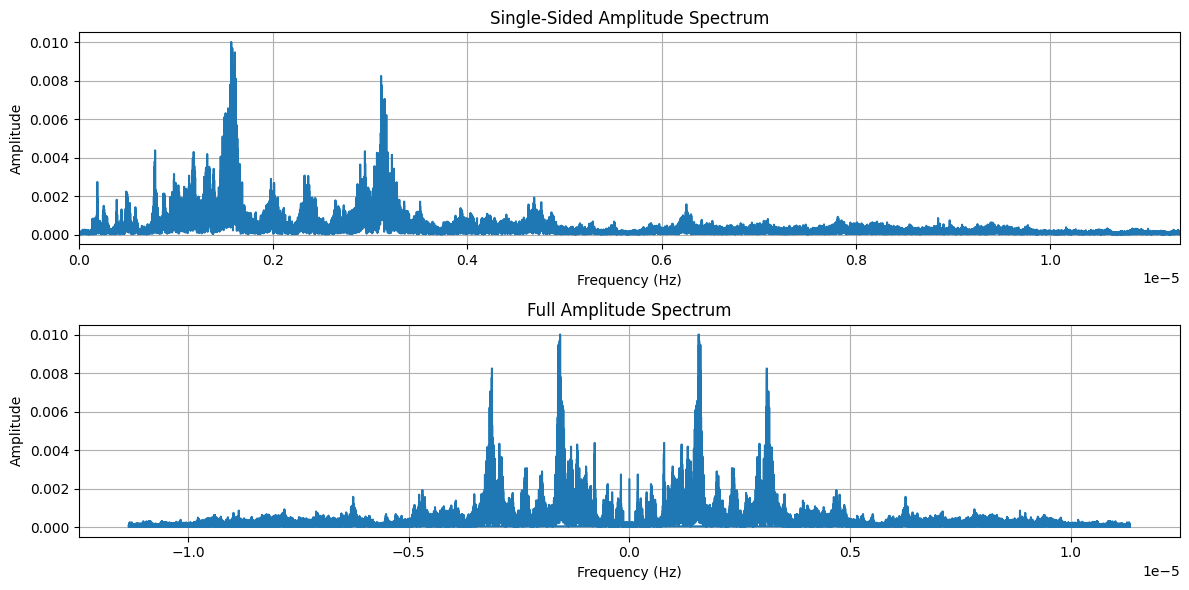

ValueError: volume and kernel should have the same dimensionality

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq
from scipy.signal import convolve

fs= 1/44100

# Coeficientes originais do numerador de z^12 até z^0
num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]

# Denominador correspondente a z^12 (1 seguido de 12 zeros)
den = [1] + [0] * 12

H = signal.freqz(num, den, worN=8000)

print ('\n arquivo de handel.wav \n')
files.upload()
audio, file_fs = sf.read('handel.wav')
duracao_audio = len(audio)/file_fs

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(audio, fs, single_sided=True)
frequencies_full, amplitudes_full = calculate_spectrum(audio, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ('\n gráfico do handel.wav \n')
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()



# CONVOLUÇÕES

# Resposta do banheiro para o áudio handel
resposta_handel = convolve(H, audio, mode='full')

# NORMALIZAÇÃO

resposta_handel = (resposta_handel / np.max(np.abs(resposta_handel)))

# SALVANDO OS ÁUDIOS

sf.write('resposta_handel.wav', resposta_handel, fs)

# REPRODUÇÃO DOS ÁUDIOS

print("\nResposta do banheiro ao áudio handel:\n")

display(
    Audio(
        resposta_handel,
        rate=fs
    )
)

# ESPECTROS DAS RESPOSTAS

freq_handel, amp_handel = calculate_spectrum(
    resposta_handel,
    fs,
    single_sided=True
)

# PLOT DOS ESPECTROS
# ============================================================

plt.figure(figsize=(14, 8))

# Espectro da resposta ao handel
plt.subplot(2, 1, 1)

plt.plot(
    freq_handel,
    amp_handel
)

plt.title(
    'Espectro da resposta do banheiro ao áudio handel'
)

plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.xlim(0, fs / 2)

plt.tight_layout()
plt.show()

Pratica 3 Exercício 3

Pratica 3 Exercício 4

<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_957/55566510.py:45: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')
/tmp/ipykernel_957/55566510.py:31: RuntimeWarning: divide by zero encountered in log10
  magnitude_db = 20 * np.log10(np.abs(H))


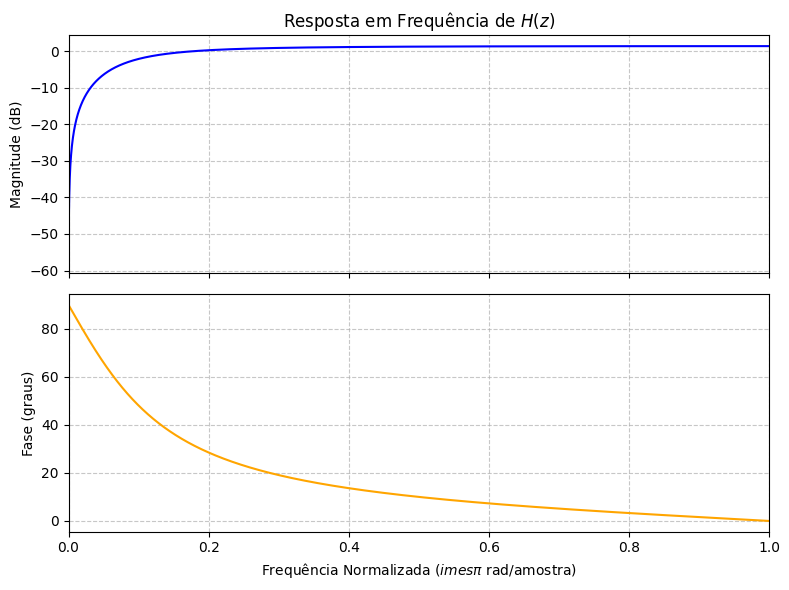

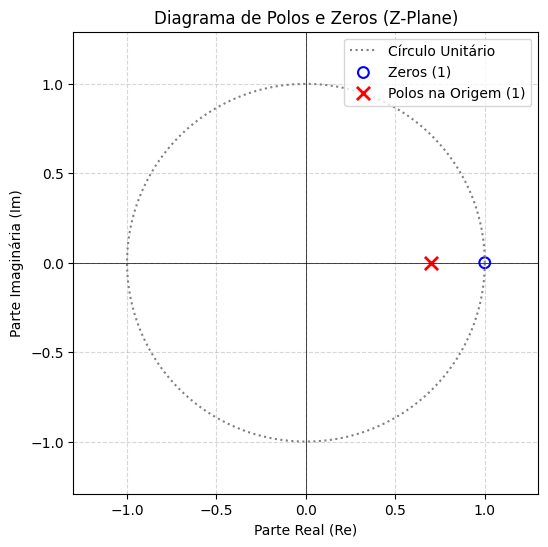

In [23]:
import numpy as np
import matplotlib.pyplot as plot
from scipy import signal

numA = [1, -1]
denA = [1, -0.7]

numB = [1, -1]
denB = [1, -0.9]

numC = [1, 0, 0, 0, -1]
denC = [1, 0, 0, 0, -0.7]

numD = [1, 0, 0, 0, -1]
denD = [1, 0, 0, 0, -0.9]

numE = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1]
denE = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0,7]

numF = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1]
denF = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0,9]

#com numA e denA *** START

# Resposta em frequencia
# Calcula a resposta em frequência (w em rad/amostra, H é complexo)
# worN=8000 define a resolução do gráfico (8000 pontos)
w, H = signal.freqz(numA, denA, worN=8000)

# Extrai Magnitude (em decibéis) e Fase (em graus)
magnitude_db = 20 * np.log10(np.abs(H))
fase_graus = np.degrees(np.unwrap(np.angle(H)))

# --- Plotando os Gráficos ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 1. Gráfico de Magnitude
ax1.plot(w / np.pi, magnitude_db, color='blue', linewidth=1.5)
ax1.set_title('Resposta em Frequência de $H(z)$')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfico de Fase
ax2.plot(w / np.pi, fase_graus, color='orange', linewidth=1.5)
ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')
ax2.set_ylabel('Fase (graus)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajusta o eixo X para ir de 0 a 1 (0 a pi rad)
ax2.set_xlim([0, 1])

plt.tight_layout()

#CALCULOS DE POLOS DE ZEROS

# Calcula analiticamente todos os zeros e polos exatos
zeros, polos, k = signal.tf2zpk(numA, denA)

# Cria a figura
fig, ax = plt.subplots(figsize=(6, 6))

# 1. Desenha o Círculo Unitário (Filtros Digitais / Tempo Discreto)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# 2. Plota os Zeros (como circunferências 'o')
ax.scatter(np.real(zeros), np.imag(zeros), s=60, marker='o',
           facecolors='none', edgecolors='blue', linewidth=1.5, label=f'Zeros ({len(zeros)})')

# 3. Plota os Polos (como 'x' vermelhos) -> Agora os 12 polos em (0,0) vão aparecer!
ax.scatter(np.real(polos), np.imag(polos), s=90, marker='x',
           color='red', linewidth=2, label=f'Polos na Origem ({len(polos)})')

# Ajustes de layout e eixos cruzados na origem
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax.set_title('Diagrama de Polos e Zeros (Z-Plane)')
ax.set_xlabel('Parte Real (Re)')
ax.set_ylabel('Parte Imaginária (Im)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Garante proporção 1:1 perfeita para o círculo não virar uma elipse
ax.axis('equal')

# Define limites ligeiramente maiores que o círculo unitário para melhor visualização
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])

plt.show()

#com numA e denA *** END

Pratica 3 Exercício 5

Pratica 3 Exercício 6

Pratica 3 Exercício 7